In [19]:
import pickle as pkl
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt 
import seaborn as sns

from tqdm import tqdm
from pathlib import Path 

In [20]:
rank_path = Path("/home/wuhlmann/BA/data/processed_data/SA/ranks")
nse_path = Path("/home/wuhlmann/BA/data/processed_data/SA/raw_NSE")

rank_file_list = list(rank_path.glob("*.p"))
nse_file_list = list(nse_path.glob("*.p"))

rank_dict = {}
nse_dict = {} 


In [21]:
for rank_path in rank_file_list: 
    
	with open(rank_path, "rb") as f: 
		rank_dict.update(pkl.load(f))
	
rank_dict = dict(sorted(rank_dict.items(), key=lambda item: int(item[0])))

for nse_path in nse_file_list: 
    
	with open(nse_path, "rb") as f: 
		nse_dict.update(pkl.load(f))
	
nse_dict = dict(sorted(nse_dict.items(), key=lambda item: int(item[0])))

In [22]:
domain_ranks_dict = {}

# Calculate the attribute sensitivity ranking per basin. 
for id in tqdm(list(nse_dict.keys())):

	# Get df.
	basin_df = nse_dict[id]

	# Create df to collect the ranks per noise level.
	basin_attr_ranks = pd.DataFrame(data=[0]*len(basin_df.index), index=basin_df.index, columns=["rank"], dtype="float")

	attr_weights = [0.1, 0.25, 0.5, 0.75, 1, 1, 0.75, 0.5, 0.25, 0.1]

	# Iterate over the noise level in the columns. 
	for col, weight in zip(basin_df.columns, attr_weights):
		
		# Sort the df by that noise level, with higher values in the NSE deltas signaling higher sensitivity.  
		order = list(basin_df.sort_values(by=col, ascending=False)[col].index)

		# Add the weighted rank of the attribute to the results dict. 
		for attr in basin_df.index:
			basin_attr_ranks.loc[attr, "rank"] += (order.index(attr)) * weight

	print(basin_attr_ranks)

	# Divide through number of noise levels to get mean rank and sort the attributes by that. 
	mean_basin_attr_ranks = basin_attr_ranks.apply(lambda x: x/len(basin_df.columns))
	mean_basin_attr_ranks.sort_values(by="rank", ascending=True, inplace=True)
	print(mean_basin_attr_ranks)
	# Attach mean_attr_ranks for each basin. 
	domain_ranks_dict[id] = mean_basin_attr_ranks

  1%|          | 9/859 [00:00<00:21, 40.17it/s]

              rank
area_calc    95.45
elev_mean    63.45
elev_ran     93.65
slope_mean   74.15
p_mean      101.05
et0_mean     46.90
arid_1       16.55
p_season     47.55
hi_prec_fr   61.05
hi_prec_du   85.45
lo_prec_fr   80.10
lo_prec_du   56.80
frac_snow    30.50
agr_fra      61.90
bare_fra     24.10
forest_fra  120.20
glac_fra    108.80
lake_fra    102.35
urban_fra     6.45
lai_max      63.75
lai_diff     78.45
gvf_max      47.70
gvf_diff     41.95
bedrk_dep   132.30
soil_poros   99.95
soil_condu   84.10
sand_fra    112.30
silt_fra     90.35
clay_fra     83.90
              rank
urban_fra    0.645
arid_1       1.655
bare_fra     2.410
frac_snow    3.050
gvf_diff     4.195
et0_mean     4.690
p_season     4.755
gvf_max      4.770
lo_prec_du   5.680
hi_prec_fr   6.105
agr_fra      6.190
elev_mean    6.345
lai_max      6.375
slope_mean   7.415
lai_diff     7.845
lo_prec_fr   8.010
clay_fra     8.390
soil_condu   8.410
hi_prec_du   8.545
silt_fra     9.035
elev_ran     9.365
area_calc   

  3%|▎         | 24/859 [00:00<00:20, 40.55it/s]

              rank
area_calc    65.95
elev_mean    47.95
elev_ran     55.55
slope_mean   57.80
p_mean       55.90
et0_mean     90.00
arid_1       57.40
p_season     70.25
hi_prec_fr   55.40
hi_prec_du   74.30
lo_prec_fr  120.30
lo_prec_du  126.75
frac_snow    42.90
agr_fra      48.60
bare_fra    104.30
forest_fra   52.90
glac_fra    126.45
lake_fra     96.05
urban_fra    22.35
lai_max      40.30
lai_diff     73.65
gvf_max      82.55
gvf_diff     77.10
bedrk_dep   128.70
soil_poros  109.35
soil_condu   53.10
sand_fra     40.50
silt_fra     88.10
clay_fra     46.75
              rank
urban_fra    2.235
lai_max      4.030
sand_fra     4.050
frac_snow    4.290
clay_fra     4.675
elev_mean    4.795
agr_fra      4.860
forest_fra   5.290
soil_condu   5.310
hi_prec_fr   5.540
elev_ran     5.555
p_mean       5.590
arid_1       5.740
slope_mean   5.780
area_calc    6.595
p_season     7.025
lai_diff     7.365
hi_prec_du   7.430
gvf_diff     7.710
gvf_max      8.255
silt_fra     8.810
et0_mean    

  4%|▍         | 34/859 [00:00<00:20, 40.70it/s]

...

 98%|█████████▊| 844/859 [00:20<00:00, 41.04it/s]

              rank
agr_fra      2.000
soil_condu   2.025
gvf_diff     2.300
p_mean       3.045
bedrk_dep    3.615
bare_fra     3.885
sand_fra     4.525
et0_mean     4.690
urban_fra    4.730
slope_mean   5.200
soil_poros   5.370
silt_fra     7.215
lai_max      7.580
frac_snow    7.640
clay_fra     7.815
lo_prec_du   8.080
arid_1       8.310
hi_prec_fr   8.525
elev_ran     8.700
p_season     9.345
forest_fra   9.510
area_calc    9.750
lo_prec_fr  10.230
elev_mean   10.560
glac_fra    10.800
lai_diff    10.825
hi_prec_du  11.170
gvf_max     11.655
lake_fra    12.025
              rank
area_calc    92.55
elev_mean    38.25
elev_ran    123.45
slope_mean   47.45
p_mean       71.35
et0_mean     38.55
arid_1       90.40
p_season    115.45
hi_prec_fr   71.30
hi_prec_du   78.35
lo_prec_fr  111.65
lo_prec_du  107.55
frac_snow    37.70
agr_fra      23.55
bare_fra     71.05
forest_fra   67.30
glac_fra     86.55
lake_fra    100.55
urban_fra    78.15
lai_max      53.85
lai_diff    132.00
gvf_max     

100%|██████████| 859/859 [00:21<00:00, 41.03it/s]

              rank
area_calc    59.30
elev_mean    92.25
elev_ran     69.70
slope_mean   89.10
p_mean       61.80
et0_mean     74.45
arid_1       55.60
p_season     98.70
hi_prec_fr   55.30
hi_prec_du   89.60
lo_prec_fr  112.15
lo_prec_du   92.65
frac_snow    98.65
agr_fra       8.10
bare_fra     58.35
forest_fra   61.45
glac_fra     65.75
lake_fra     82.70
urban_fra    12.70
lai_max      53.95
lai_diff    128.40
gvf_max      98.20
gvf_diff     66.35
bedrk_dep   107.80
soil_poros   81.40
soil_condu   35.15
sand_fra     58.10
silt_fra     44.90
clay_fra     98.65
              rank
agr_fra      0.810
urban_fra    1.270
soil_condu   3.515
silt_fra     4.490
lai_max      5.395
hi_prec_fr   5.530
arid_1       5.560
sand_fra     5.810
bare_fra     5.835
area_calc    5.930
forest_fra   6.145
p_mean       6.180
glac_fra     6.575
gvf_diff     6.635
elev_ran     6.970
et0_mean     7.445
soil_poros   8.140
lake_fra     8.270
slope_mean   8.910
hi_prec_du   8.960
elev_mean    9.225
lo_prec_du  

100%|██████████| 859/859 [00:21<00:00, 40.51it/s]


In [23]:
strata_ids = pd.read_table("/home/wuhlmann/BA/data/processed_data/test_splits/strata_ids_incl_651.txt", header=0, sep=",")
strata_ids.set_index("ID", inplace=True)

lamah_gdf = gpd.read_file("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
lamah_gdf.set_index("ID", inplace=True)
lamah_gdf["strata"] = strata_ids["0"]
lamah_gdf.sort_index(ascending=True, inplace=True)

In [24]:
for id in domain_ranks_dict.keys():

	attr_ranks_list = list(domain_ranks_dict[id].index)

	lamah_gdf.loc[int(id), "last_rank"] = attr_ranks_list[-1]
	lamah_gdf.loc[int(id), "1st_rank"] = attr_ranks_list[0]

	for attr in attr_ranks_list: 
		
		lamah_gdf.loc[int(id), f"{attr}_rank"] = attr_ranks_list.index(attr)

Display all attributes ranks over the domain.

30it [00:23,  1.27it/s]


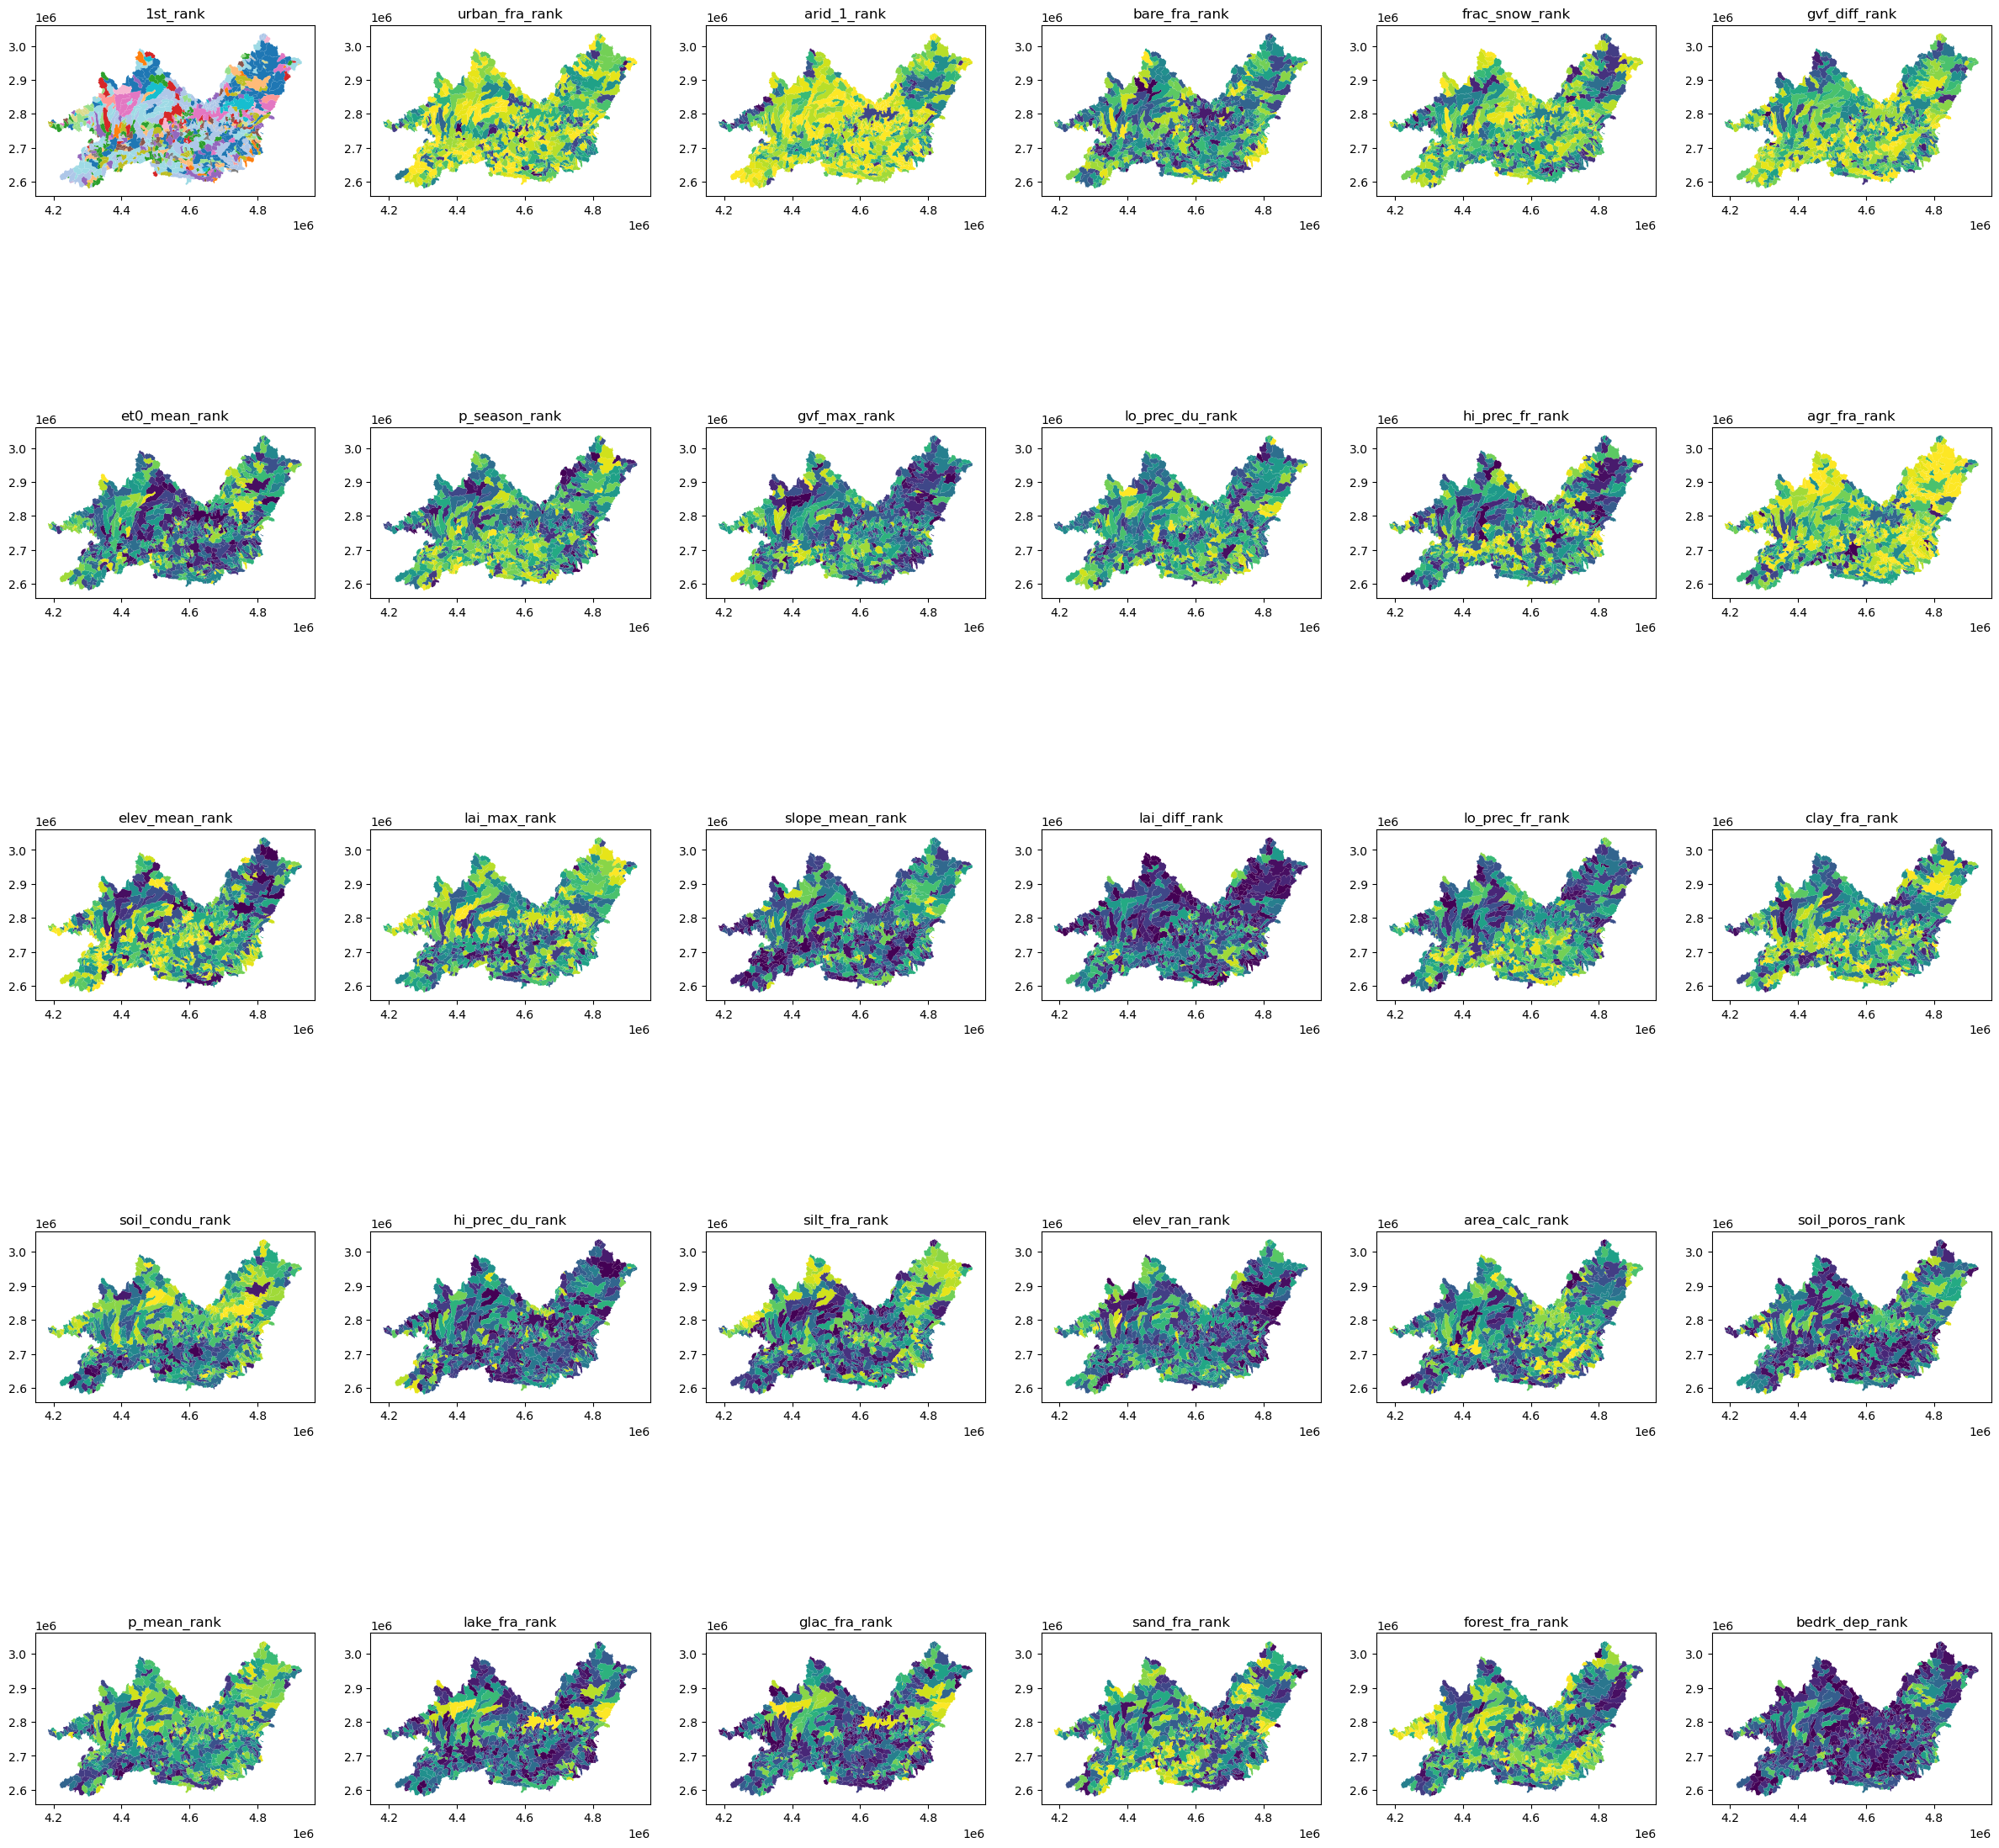

In [25]:
fig, axs = plt.subplots(5,6, figsize=(30,30))

for ax, attr in tqdm(zip(axs.ravel(), list(lamah_gdf.columns[-30:]))):
	
	lamah_gdf.plot(column=attr, ax=ax, cmap="viridis_r" if not attr == "1st_rank" else "tab20")
	ax.set_title(attr)


In [26]:
lamah_gdf.columns

Index(['area_calc', 'elev_mean', 'elev_med', 'elev_std', 'elev_ran',
       'slope_mean', 'mvert_dist', 'mvert_ang', 'elon_ratio', 'strm_dens',
       'p_mean', 'et0_mean', 'eta_mean', 'arid_1', 'arid_2', 'p_season',
       'frac_snow', 'hi_prec_fr', 'hi_prec_du', 'hi_prec_ti', 'lo_prec_fr',
       'lo_prec_du', 'lo_prec_ti', 'lc_dom', 'agr_fra', 'bare_fra',
       'forest_fra', 'glac_fra', 'lake_fra', 'urban_fra', 'lai_max',
       'lai_diff', 'ndvi_max', 'ndvi_min', 'gvf_max', 'gvf_diff', 'bedrk_dep',
       'root_dep', 'soil_poros', 'soil_condu', 'soil_tawc', 'sand_fra',
       'silt_fra', 'clay_fra', 'grav_fra', 'oc_fra', 'gc_dom', 'gc_ig_fra',
       'gc_mt_fra', 'gc_pa_fra', 'gc_pb_fra', 'gc_pi_fra', 'gc_py_fra',
       'gc_sc_fra', 'gc_sm_fra', 'gc_ss_fra', 'gc_su_fra', 'gc_va_fra',
       'gc_vb_fra', 'gc_wb_fra', 'geol_perme', 'geol_poros', 'NEXTDOWNID',
       'geometry', 'strata', 'last_rank', '1st_rank', 'urban_fra_rank',
       'arid_1_rank', 'bare_fra_rank', 'frac_snow_ra

In [29]:
lamah_gdf_only_rank = lamah_gdf.drop(columns=lamah_gdf.columns[:63])

average_attr_rank = {}

for col in lamah_gdf_only_rank.columns[4:]: 
    
	average_attr_rank[col] = lamah_gdf_only_rank[col].mean()


average_attr_rank = dict(sorted(average_attr_rank.items(), key=lambda item: item[1]))

In [30]:
attr_categories = {
    "geomorph": ["area_calc", "slope_mean", "elev_mean", "elev_ran", "bedrk_dep"],
    "precip": ["p_mean", "p_season", "arid_1", "et0_mean", "frac_snow", "lo_prec_du", "lo_prec_fr", "hi_prec_du", "hi_prec_fr"],
    "landcover": ["urban_fra", "agr_fra", "forest_fra", "bare_fra", "lake_fra", "glac_fra"],
    "vegetation": ["gvf_max", "gvf_diff", "lai_max", "lai_diff"],
    "soil": ["clay_fra", "sand_fra", "silt_fra", "soil_condu", "soil_poros"]
}

In [31]:
lamah_gdf

,area_calc,elev_mean,elev_med,elev_std,elev_ran,slope_mean,mvert_dist,mvert_ang,elon_ratio,strm_dens,...,silt_fra_rank,elev_ran_rank,area_calc_rank,soil_poros_rank,p_mean_rank,lake_fra_rank,glac_fra_rank,sand_fra_rank,forest_fra_rank,bedrk_dep_rank
ID,,,,,,,,,,,,,,,,,,,,,
1,442.343,1289,1225,654,2766,333,53.2,7,0.446,0.87,...,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0
2,102.287,1775,1827,422,2097,368,18.8,283,0.607,0.66,...,18.0,26.0,23.0,14.0,11.0,19.0,15.0,12.0,27.0,22.0
3,434.012,1861,1944,529,2632,370,38.7,325,0.607,0.63,...,26.0,17.0,7.0,15.0,22.0,14.0,5.0,1.0,10.0,8.0
4,66.286,1894,1907,378,1843,393,12.5,257,0.737,0.80,...,22.0,18.0,20.0,28.0,12.0,11.0,4.0,16.0,10.0,23.0
5,72.448,1774,1796,468,2336,432,13.6,40,0.704,0.63,...,21.0,28.0,27.0,24.0,23.0,15.0,8.0,6.0,20.0,19.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
878,379.712,436,444,66,426,62,35.0,126,0.628,0.38,...,9.0,26.0,19.0,20.0,23.0,25.0,24.0,4.0,27.0,15.0
879,566.360,442,451,90,489,45,48.2,105,0.558,0.36,...,4.0,28.0,20.0,15.0,2.0,26.0,22.0,0.0,19.0,7.0
880,103.067,307,302,60,300,74,20.0,100,0.573,0.43,...,5.0,27.0,16.0,24.0,4.0,26.0,23.0,1.0,21.0,12.0


In [32]:
for id in lamah_gdf_only_rank.index: 
	
	basin_top_attr = lamah_gdf_only_rank.loc[id, "1st_rank"]

	for category, attr_list in attr_categories.items():

		if basin_top_attr in attr_list: 
			lamah_gdf_only_rank.loc[id, "top_attr_category"] = category 

In [33]:
lamah_gdf_only_rank["top_attr_category"].value_counts()

top_attr_category
landcover     291
precip        262
geomorph      116
soil          102
vegetation     88
Name: count, dtype: int64

In [34]:
average_attr_rank

{'arid_1_rank': 6.875436554132713,
 'urban_fra_rank': 7.282887077997672,
 'agr_fra_rank': 7.965075669383004,
 'gvf_diff_rank': 9.09545983701979,
 'elev_mean_rank': 9.428405122235157,
 'frac_snow_rank': 10.476135040745053,
 'forest_fra_rank': 12.474970896391152,
 'lai_max_rank': 12.49708963911525,
 'clay_fra_rank': 12.559953434225845,
 'hi_prec_fr_rank': 12.663562281722934,
 'p_season_rank': 13.060535506402793,
 'sand_fra_rank': 13.19441210710128,
 'soil_condu_rank': 13.284051222351572,
 'p_mean_rank': 13.682188591385332,
 'lo_prec_fr_rank': 13.729918509895228,
 'lo_prec_du_rank': 13.755529685681024,
 'area_calc_rank': 14.171129220023284,
 'bare_fra_rank': 14.271245634458673,
 'et0_mean_rank': 15.40512223515716,
 'gvf_max_rank': 15.434225844004656,
 'silt_fra_rank': 15.940628637951106,
 'soil_poros_rank': 17.534342258440045,
 'elev_ran_rank': 17.70663562281723,
 'hi_prec_du_rank': 17.918509895227007,
 'slope_mean_rank': 18.17811408614668,
 'glac_fra_rank': 18.431897555296857,
 'lai_diff

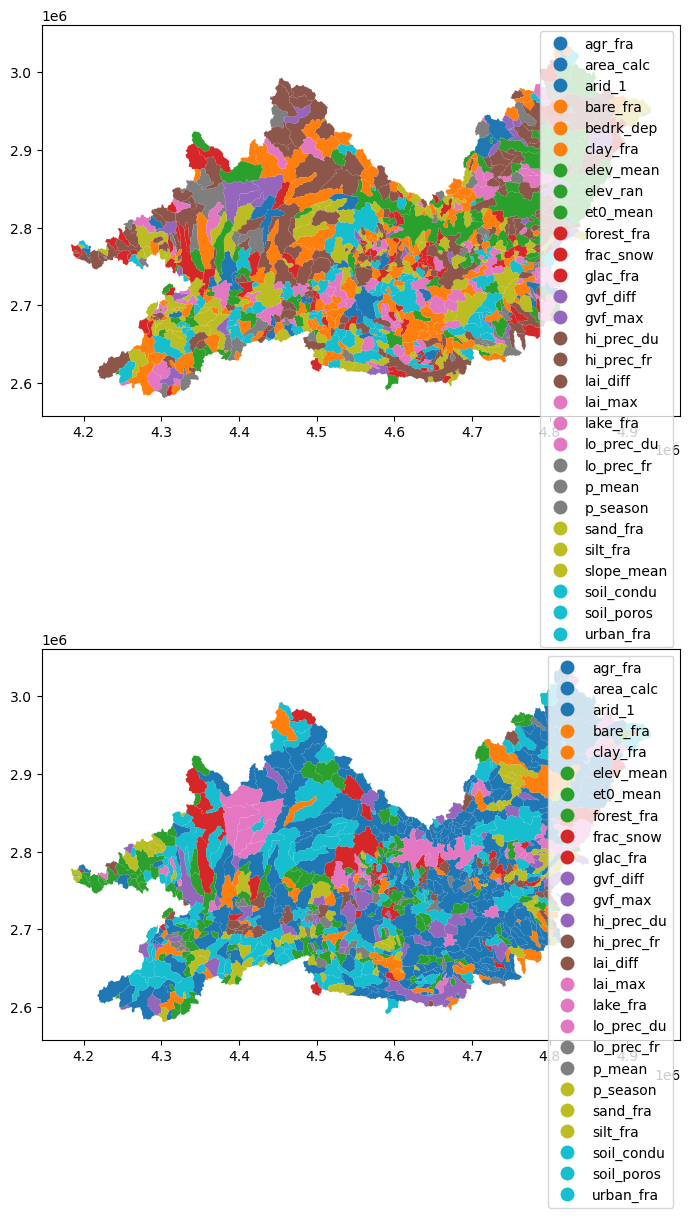

In [36]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

kmeans = KMeans(2, random_state=1277)

#cluster_labels = kmeans.fit_predict(lamah_gdf_only_rank.iloc[:,3:])

#lamah_gdf_only_rank["labels"] = cluster_labels

fig, ax = plt.subplots(2,1, figsize=(12,12))

lamah_gdf_only_rank.plot(column="last_rank", legend=True, ax=ax[0])
lamah_gdf_only_rank.plot(column="1st_rank", legend=True, ax=ax[1])

plt.tight_layout()